## lets have a look at some of these uggo tracks then shall we?

Take data and MC sample using the same psf and then the data psf and compare them

Data is 15590, 140426, 9mm voxelisation, 36/42mm blob radii
MC is th_port1a_dep_202602_subsample, 250326_9, 9mm voxelisation, 36/42mm blob radii

| Type | run | timestamp | voxelisation (mm) | blob/scan (mm) |
| ---- | --: | --------: | ----------------: | -------------: |
| Data |  15590 | 140426 | 9 | 36/42 |
| MC   | th_port1a_dep_202602_subsample | 250326_9 | 9 | 36/42 |
| Data | 15590 | 150426_datapsf | 9 | 36/42 |

In [1]:
import sys
sys.path.append("/home/e78368jw/Documents/NEXT_CODE/")
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import FOM_functions as FOM_func
import functions_HE as func
from pathlib import Path
import traceback
from tqdm import tqdm

from invisible_cities.io.dst_io           import load_dst, load_dsts, df_writer

In [2]:
#func.raw_plotter()
#func.plotter_3d
generic_path = '/home/e78368jw/Documents/NEXT_CODE/next_misc/cluster_analysis_code/year_of_horse_notebooks/beer_thekla_resolution/data/'
data_MCPSF   = f'{generic_path}/140426/ldc1'
#data_dataPSF = f'{generic_path}/no_existo'
MC           = f'{generic_path}/250326_9/ldc1'


def load_track(data_path, many_files = False):
    full_path = list(Path(f'{data_path}/').rglob('*.h5'))
    tdst_MC = []
    # this is too heavy 
    if many_files:
        for f in tqdm(full_path):
            try:
                df = load_dst(f, 'DECO', 'Events')
            except Exception as e:
                print(traceback.format_exc())
                df = pd.DataFrame()
            tdst_MC.append(df)

        return pd.concat(tdst_MC)
    else:
        return load_dst(full_path[1], 'DECO', 'Events')

tdst_MC        = load_track(MC)
tdst_dataMCPSF = load_track(data_MCPSF)

In [3]:
display(tdst_MC)
display(tdst_dataMCPSF)

,event,npeak,X,Y,Z,E,Xpeak,Ypeak,time,nsipm,Xrms,Yrms
0,15200000,1.0,165.875,175.575,937.265681,8.455494e-09,111.704700,182.213813,3.040000e+13,0,0,0
1,15200000,1.0,165.875,176.575,937.265681,1.228211e-08,111.704700,182.213813,3.040000e+13,0,0,0
2,15200000,1.0,165.875,177.575,937.265681,1.622430e-08,111.704700,182.213813,3.040000e+13,0,0,0
3,15200000,1.0,165.875,178.575,937.265681,1.971889e-08,111.704700,182.213813,3.040000e+13,0,0,0
4,15200000,1.0,165.875,179.575,937.265681,2.211083e-08,111.704700,182.213813,3.040000e+13,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
10213304,15200184,0.0,-154.125,-17.425,601.728105,8.211277e-09,-138.348963,21.536893,3.040037e+13,0,0,0
10213305,15200184,0.0,-154.125,-16.425,601.728105,1.200560e-08,-138.348963,21.536893,3.040037e+13,0,0,0
10213306,15200184,0.0,-154.125,-15.425,601.728105,1.378538e-08,-138.348963,21.536893,3.040037e+13,0,0,0
10213307,15200184,0.0,-154.125,-14.425,601.728105,1.232970e-08,-138.348963,21.536893,3.040037e+13,0,0,0


,event,npeak,X,Y,Z,E,Xpeak,Ypeak,time,nsipm,Xrms,Yrms
0,66501,28.0,-147.125,88.575,766.031500,9.770198e-09,-42.113010,47.886678,1.752078e+09,0,0,0
1,66501,28.0,-147.125,89.575,766.031500,1.187322e-08,-42.113010,47.886678,1.752078e+09,0,0,0
2,66501,28.0,-147.125,90.575,766.031500,1.118908e-08,-42.113010,47.886678,1.752078e+09,0,0,0
3,66501,28.0,-147.125,91.575,766.031500,8.255114e-09,-42.113010,47.886678,1.752078e+09,0,0,0
4,66501,28.0,-146.125,84.575,766.031500,7.330754e-09,-42.113010,47.886678,1.752078e+09,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
578617,67208,25.0,288.875,141.575,763.336375,3.830021e-09,109.388824,67.849036,1.752078e+09,0,0,0
578618,67208,25.0,289.875,136.575,763.336375,4.094972e-09,109.388824,67.849036,1.752078e+09,0,0,0
578619,67208,25.0,289.875,137.575,763.336375,5.803350e-09,109.388824,67.849036,1.752078e+09,0,0,0
578620,67208,25.0,289.875,138.575,763.336375,5.518919e-09,109.388824,67.849036,1.752078e+09,0,0,0


In [4]:
tdst_MC.event.unique()

array([15200000, 15200001, 15200002, 15200003, 15200004, 15200005,
       15200006, 15200007, 15200008, 15200009, 15200010, 15200011,
       15200012, 15200013, 15200014, 15200015, 15200016, 15200017,
       15200018, 15200019, 15200020, 15200021, 15200022, 15200023,
       15200024, 15200025, 15200026, 15200027, 15200028, 15200029,
       15200030, 15200031, 15200032, 15200033, 15200034, 15200035,
       15200036, 15200037, 15200038, 15200039, 15200040, 15200041,
       15200042, 15200043, 15200044, 15200045, 15200046, 15200047,
       15200048, 15200049, 15200050, 15200051, 15200052, 15200053,
       15200054, 15200055, 15200056, 15200057, 15200058, 15200059,
       15200060, 15200061, 15200062, 15200063, 15200064, 15200065,
       15200066, 15200067, 15200068, 15200069, 15200070, 15200071,
       15200072, 15200073, 15200074, 15200075, 15200076, 15200077,
       15200078, 15200079, 15200080, 15200081, 15200082, 15200083,
       15200084, 15200085, 15200086, 15200087, 15200088, 15200

Energy sum: 1.5686476026938507 MeV


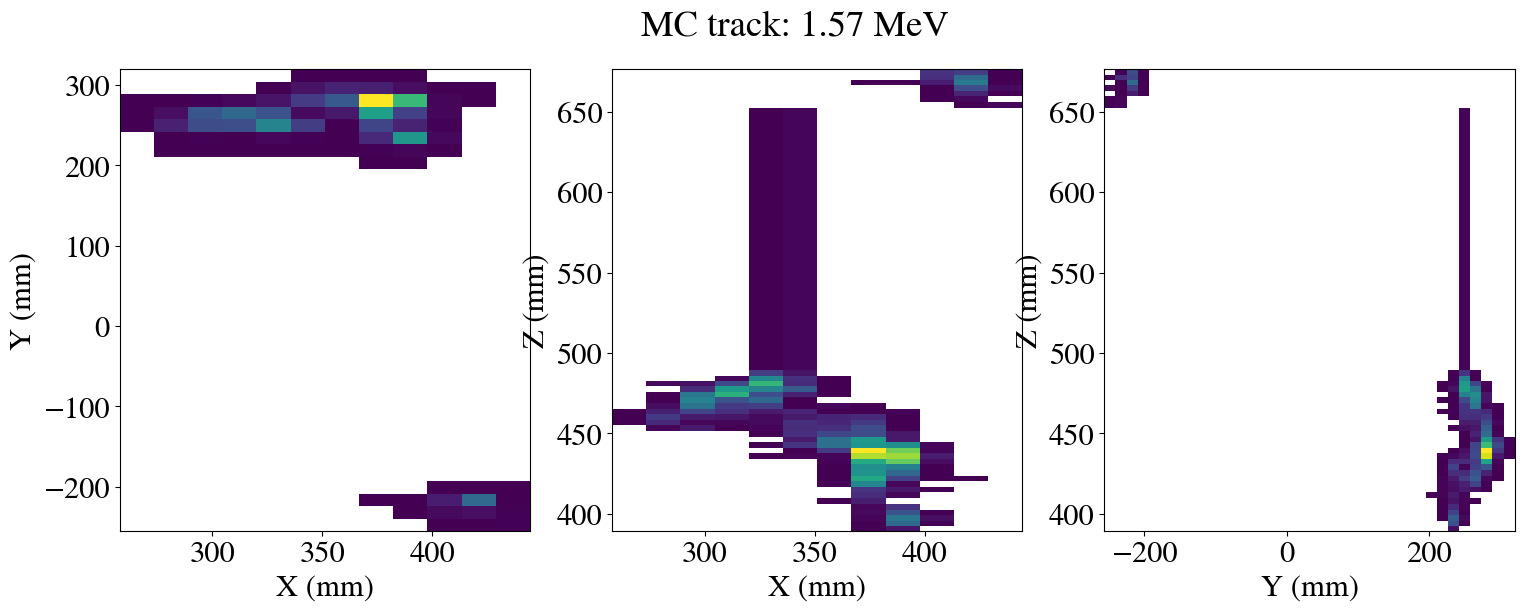

In [19]:
MC_evt = tdst_MC.event.unique()[6]
tdst_MC_eoi = tdst_MC[tdst_MC.event == MC_evt]
print(f'Energy sum: {tdst_MC_eoi.E.sum()} MeV')
func.raw_plotter(tdst_MC_eoi, MC_evt, param = 'E', title = f'MC track: {tdst_MC_eoi.E.sum():.2f} MeV') 


In [13]:
DATA_evt = tdst_dataMCPSF.event.unique()[7]
tdst_DATA_eoi = tdst_dataMCPSF[tdst_dataMCPSF.event == DATA_evt]
print(f'Energy sum: {tdst_DATA_eoi.E.sum()} MeV')
func.raw_plotter(tdst_DATA_eoi, DATA_evt, param = 'E', title = f'Data (MC psf) track: {tdst_DATA_eoi.E.sum():.2f} MeV') 
 



IndexError: index 7 is out of bounds for axis 0 with size 7